# Phase 1 R&D — Tuning Ablations (v2: on the shared rank-metrics + real-data foundation)

`classification_bakeoff.ipynb` established the fair comparison: same ~259-example eval
set (238 real MITRE procedure examples + hand-written synthetics/real excerpts), same
rank-based metrics (MRR / MAP / Recall@k), same `EVAL_N=80` stratified sample (seed 42
— **this notebook reuses the identical sample**, so numbers here are directly
comparable to that notebook's, not a new, incomparable run).

This notebook holds that foundation fixed and changes **one thing at a time**, each
ablation producing a single metric-delta table, building toward a final tuned
configuration:

1. **Embedding model** (`bge-small` / `bge-base` / `bge-large`) × query-instruction
   prefix on/off.
2. **Corpus representation** (name-only → +tactics → +description), holding the best
   embedding config fixed.
3. **Reranker model** (`ms-marco-MiniLM` vs `bge-reranker-base`).
4. **LLM size (3B vs 7B) × prompt variant** (anchoring-bug-style vs the fixed
   ranking-format prompt) — isolates the prompt-fix effect from the model-capability
   effect, on a smaller sub-sample (LLM ablations are the expensive part; see setup).
5. **`HYBRID_RETRIEVAL_N` sweep** — is the value chosen by the recall-ceiling heuristic
   in the bake-off actually optimal for Method C once an LLM is in the loop?

The final section assembles the winning choices into one tuned configuration and
re-validates it on the full `EVAL_N` sample.

## 1. Setup — same foundation, same sample

Reuses `EVAL_N=80` and `SAMPLE_SEED=42` from the bake-off notebook so the stratified
sample is byte-for-byte identical. LLM ablations (4-5) additionally use a smaller,
deterministic `TUNING_N`-sized sub-sample (the first `TUNING_N` of `sample`) purely to
keep ablation runtime bounded — noted explicitly since a smaller n means noisier
absolute numbers, though the *relative* comparison within an ablation (same sub-sample
for every variant) stays fair.

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_research_dir() -> Path:
    here = Path.cwd()
    for candidate in (here, here / "research", here.parent):
        if (candidate / "lib" / "attack_data.py").exists():
            return candidate
    raise RuntimeError("Could not locate the research/ directory — run from research/.")


RESEARCH_DIR = _find_research_dir()
DATA_DIR = RESEARCH_DIR / "data"
sys.path.insert(0, str(RESEARCH_DIR))

from lib import attack_data, eval_data, metrics, ollama_client, rerank  # noqa: E402

EVAL_N = 80
SAMPLE_SEED = 42
TUNING_N = 24          # smaller sub-sample for the LLM ablations (4-5) — cost containment
QUERY_INSTRUCTION = "Represent this sentence for searching relevant passages: "

cache = ollama_client.ResponseCache(DATA_DIR / ".llm_cache.json")

techniques = attack_data.fetch_and_cache(DATA_DIR / "attack_ics_techniques.json")
technique_by_id = {t.id: t for t in techniques}
valid_ids = set(technique_by_id)
corpus_texts_default = [f"{t.name}. {t.description}" for t in techniques]

examples = eval_data.load_eval_set(
    DATA_DIR / "procedure_examples.jsonl",
    DATA_DIR / "labeled_dataset.jsonl",
    DATA_DIR / "labeled_dataset.local.jsonl",
)
eval_data.validate_technique_ids(examples, valid_ids)
examples = eval_data.compute_name_absent(examples, technique_by_id)
eval_data.assert_no_leakage(corpus_texts_default, examples)

sample = eval_data.sample_by_technique(examples, EVAL_N, seed=SAMPLE_SEED)
tuning_sample = sample[:TUNING_N]

print(f"{len(techniques)} techniques | {len(examples)} eval examples")
print(f"sample: {len(sample)} (same seed as bake-off)  |  tuning_sample: {len(tuning_sample)}")

available = ollama_client.list_models()
for m in ("qwen2.5:3b", "qwen2.5:7b"):
    assert m in available, f"Model '{m}' not found. Run:  ollama pull {m}"
print("Ollama models OK:", [m for m in available if m in ("qwen2.5:3b", "qwen2.5:7b")])

c:\Users\USER\OneDrive\Desktop\Personal projects\CTI-automation-mvp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded techniques from cache: c:\Users\USER\OneDrive\Desktop\Personal projects\CTI-automation-mvp\research\data\attack_ics_techniques.json
79 techniques | 259 eval examples
sample: 80 (same seed as bake-off)  |  tuning_sample: 24
Ollama models OK: ['qwen2.5:7b', 'qwen2.5:3b']


## 2. Ablation 1 — Embedding model × query-instruction prefix

Corpus representation held fixed at `name + description` (the bake-off's default)
while testing 3 embedding models × instruction on/off (6 configs), scored on the full
`sample` (embeddings are cheap — no LLM cost here).

In [2]:
from fastembed import TextEmbedding


def l2_normalise(mat: np.ndarray) -> np.ndarray:
    return mat / np.linalg.norm(mat, axis=1, keepdims=True)


def build_ranker(model_name: str, corpus_texts: list[str]):
    model = TextEmbedding(model_name=model_name)
    vecs = l2_normalise(np.array(list(model.embed(corpus_texts))))

    def rank(text: str, instruction: str = "") -> list[str]:
        q = np.array(list(model.embed([instruction + text])))[0]
        q = q / np.linalg.norm(q)
        sims = vecs @ q
        order = np.argsort(-sims)
        return [techniques[i].id for i in order]

    return rank


def score_ranker(rank_fn, instruction: str, examples_subset) -> metrics.RankMetrics:
    results = [
        metrics.MethodResult(
            report_id=ex.id, true_ids=ex.true_technique_ids,
            ranked_ids=rank_fn(ex.behavior_text, instruction),
        )
        for ex in examples_subset
    ]
    return metrics.rank_score_method("cfg", results)


EMBEDDING_MODELS = ["BAAI/bge-small-en-v1.5", "BAAI/bge-base-en-v1.5", "BAAI/bge-large-en-v1.5"]

ablation1_rows = []
ablation1_rankers = {}
for model_name in EMBEDDING_MODELS:
    t0 = time.time()
    rank_fn = build_ranker(model_name, corpus_texts_default)
    ablation1_rankers[model_name] = rank_fn
    for use_instr in (False, True):
        instr = QUERY_INSTRUCTION if use_instr else ""
        s = score_ranker(rank_fn, instr, sample)
        ablation1_rows.append(
            {"embedding_model": model_name.split("/")[-1], "instruction": use_instr,
             "MRR": round(s.mrr, 3), "MAP": round(s.map, 3), "Recall@3": round(s.recall_at_k[3], 3)}
        )
    print(f"{model_name}: done ({time.time()-t0:.0f}s)")

ablation1_table = pd.DataFrame(ablation1_rows).set_index(["embedding_model", "instruction"])
ablation1_table

BAAI/bge-small-en-v1.5: done (2s)
BAAI/bge-base-en-v1.5: done (7s)
BAAI/bge-large-en-v1.5: done (30s)


MRR    MAP  Recall@3
embedding_model   instruction                        
bge-small-en-v1.5 False        0.510  0.507     0.581
                  True         0.489  0.485     0.544
bge-base-en-v1.5  False        0.529  0.521     0.550
                  True         0.511  0.506     0.562
bge-large-en-v1.5 False        0.526  0.523     0.562
                  True         0.496  0.495     0.569

In [3]:
best_row = max(ablation1_rows, key=lambda r: r["MRR"])
BEST_EMBEDDING_MODEL = next(m for m in EMBEDDING_MODELS if m.split("/")[-1] == best_row["embedding_model"])
BEST_INSTRUCTION = QUERY_INSTRUCTION if best_row["instruction"] else ""
print(f"-> Best: {BEST_EMBEDDING_MODEL} , instruction={best_row['instruction']} (MRR={best_row['MRR']})")

-> Best: BAAI/bge-base-en-v1.5 , instruction=False (MRR=0.529)


## 3. Ablation 2 — Corpus representation

Holding the winning embedding model + instruction setting fixed, does enriching the
embedded technique text (beyond just the name) actually help?

In [4]:
def build_corpus_texts(mode: str) -> list[str]:
    if mode == "name_only":
        return [t.name for t in techniques]
    if mode == "name_tactics":
        return [f"{t.name} ({', '.join(t.tactics)})" for t in techniques]
    if mode == "name_tactics_description":
        return [f"{t.name} ({', '.join(t.tactics)}). {t.description}" for t in techniques]
    raise ValueError(mode)


ablation2_rows = []
ablation2_rankers = {}
for mode in ("name_only", "name_tactics", "name_tactics_description"):
    corpus = build_corpus_texts(mode)
    rank_fn = build_ranker(BEST_EMBEDDING_MODEL, corpus)
    ablation2_rankers[mode] = rank_fn
    s = score_ranker(rank_fn, BEST_INSTRUCTION, sample)
    ablation2_rows.append(
        {"corpus_representation": mode, "MRR": round(s.mrr, 3), "MAP": round(s.map, 3),
         "Recall@3": round(s.recall_at_k[3], 3)}
    )

ablation2_table = pd.DataFrame(ablation2_rows).set_index("corpus_representation")
ablation2_table

,MRR,MAP,Recall@3
corpus_representation,,,
name_only,0.335,0.330,0.369
name_tactics,0.324,0.318,0.406
name_tactics_description,0.508,0.501,0.588


In [5]:
best_repr = max(ablation2_rows, key=lambda r: r["MRR"])["corpus_representation"]
print(f"-> Best corpus representation: {best_repr}")
BEST_CORPUS_TEXTS = build_corpus_texts(best_repr)
best_rank_fn = ablation2_rankers[best_repr]


def best_embedding_rank(text: str) -> list[str]:
    return best_rank_fn(text, BEST_INSTRUCTION)

-> Best corpus representation: name_tactics_description


## 4. Ablation 3 — Reranker model

Using the tuned embedding config for retrieval (`HYBRID_RETRIEVAL_N=30`, matching the
bake-off's recall-ceiling choice), compare two cross-encoder rerankers.

In [6]:
HYBRID_RETRIEVAL_N = 30  # from the bake-off notebook's recall@N ceiling analysis

# Retrieval (cheap) computed once with the tuned embedding config.
retrieval_by_id = {ex.id: best_embedding_rank(ex.behavior_text)[:HYBRID_RETRIEVAL_N] for ex in sample}

RERANKER_MODELS = ["Xenova/ms-marco-MiniLM-L-6-v2", "BAAI/bge-reranker-base"]

ablation3_rows = []
for model_name in RERANKER_MODELS:
    t0 = time.time()
    rr = rerank.CrossEncoderReranker(model_name)
    results = []
    for ex in sample:
        candidate_ids = retrieval_by_id[ex.id]
        candidate_texts = [
            (tid, f"{technique_by_id[tid].name}. {technique_by_id[tid].description_full}")
            for tid in candidate_ids
        ]
        reranked = rr.rerank(ex.behavior_text, candidate_texts)
        results.append(
            metrics.MethodResult(
                report_id=ex.id, true_ids=ex.true_technique_ids,
                ranked_ids=[c.technique_id for c in reranked],
            )
        )
    s = metrics.rank_score_method(model_name, results)
    ablation3_rows.append(
        {"reranker_model": model_name.split("/")[-1], "MRR": round(s.mrr, 3),
         "MAP": round(s.map, 3), "Recall@3": round(s.recall_at_k[3], 3)}
    )
    print(f"{model_name}: done ({time.time()-t0:.0f}s)")

ablation3_table = pd.DataFrame(ablation3_rows).set_index("reranker_model")
ablation3_table

Xenova/ms-marco-MiniLM-L-6-v2: done (82s)


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
c:\Users\USER\OneDrive\Desktop\Personal projects\CTI-automation-mvp\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\AppData\Local\Temp\fastembed_cache\models--BAAI--bge-reranker-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see 

BAAI/bge-reranker-base: done (807s)


,MRR,MAP,Recall@3
reranker_model,,,
ms-marco-MiniLM-L-6-v2,0.545,0.542,0.606
bge-reranker-base,0.556,0.550,0.600


In [7]:
best_reranker_row = max(ablation3_rows, key=lambda r: r["MRR"])
BEST_RERANKER_MODEL = next(m for m in RERANKER_MODELS if m.split("/")[-1] == best_reranker_row["reranker_model"])
print(f"-> Best reranker: {BEST_RERANKER_MODEL} (MRR={best_reranker_row['MRR']})")

-> Best reranker: BAAI/bge-reranker-base (MRR=0.556)


## 5. Ablation 4 — LLM size × prompt variant

Isolates two effects on the `tuning_sample` (smaller, for cost containment):
**prompt-fix** (anchoring-bug-style prompt vs. the fixed ranking-format prompt) and
**model-capability** (3B vs 7B), 2×2 = 4 configs. Both prompts ask for the full
79-technique catalogue (Method B's harder, no-retrieval setting) — the format that
most exposed anchoring/under-prediction previously.

In [8]:
_catalogue = "\n".join(f"{t.id}: {t.name} - {t.description[:110]}" for t in techniques)

# The ORIGINAL, flawed prompt style: a real technique ID as the JSON example
# (anchoring risk), "at most N" (invites under-prediction), free-form JSON (no schema).
def build_prompt_baseline(behavior_text: str) -> str:
    return f"""You are a cyber threat intelligence analyst mapping attacker behaviour to \
MITRE ATT&CK for ICS techniques.

TECHNIQUE CATALOGUE (ID: name - description):
{_catalogue}

BEHAVIOUR TO CLASSIFY:
"{behavior_text}"

Choose the technique IDs that best match the behaviour, most relevant first.
Use ONLY IDs from the catalogue above. Include at most 5.
Reply with ONLY this JSON shape and nothing else:
{{"predicted_techniques": [{{"technique_id": "T0836", "rank": 1}}]}}"""


# The FIXED prompt: neutral placeholder, exact ranked count required, schema-enforced.
def build_prompt_fixed(behavior_text: str) -> str:
    return f"""You are a cyber threat intelligence analyst mapping attacker behaviour to \
MITRE ATT&CK for ICS techniques.

TECHNIQUE CATALOGUE (ID: name - description):
{_catalogue}

BEHAVIOUR TO CLASSIFY:
"{behavior_text}"

Always return exactly 5 entries, ranked most-confident first — even entries you are \
unsure about; ranking position is what gets scored. Reply with ONLY this JSON shape:
{{"predicted_techniques": [
  {{"technique_id": "<id>", "rank": 1}}, {{"technique_id": "<id>", "rank": 2}},
  {{"technique_id": "<id>", "rank": 3}}, {{"technique_id": "<id>", "rank": 4}},
  {{"technique_id": "<id>", "rank": 5}}
]}}
Replace <id> with a real technique ID from the catalogue above. A single behaviour \
often maps to more than one technique — rank plausible alternatives too."""


def run_llm(model: str, prompt_fn, structured: bool, label: str) -> list[metrics.MethodResult]:
    results = []
    t0 = time.time()
    for ex in tuning_sample:
        prompt = prompt_fn(ex.behavior_text)
        if structured:
            pred = ollama_client.classify_structured(
                model, prompt, valid_ids, max_predictions=5, min_predictions=5, cache=cache
            )
        else:
            pred = ollama_client.classify(model, prompt, valid_ids, cache=cache)
        results.append(
            metrics.MethodResult(
                report_id=ex.id, true_ids=ex.true_technique_ids, ranked_ids=pred.ranked_ids,
                parse_failure=pred.parse_failure, hallucinated_id_count=len(pred.hallucinated),
            )
        )
    print(f"{label}: done ({time.time()-t0:.0f}s, {len(tuning_sample)} calls)")
    return results


ablation4_configs = [
    ("3B, baseline prompt", "qwen2.5:3b", build_prompt_baseline, False),
    ("3B, fixed prompt", "qwen2.5:3b", build_prompt_fixed, True),
    ("7B, baseline prompt", "qwen2.5:7b", build_prompt_baseline, False),
    ("7B, fixed prompt", "qwen2.5:7b", build_prompt_fixed, True),
]

ablation4_rows = []
ablation4_results = {}
for label, model, prompt_fn, structured in ablation4_configs:
    results = run_llm(model, prompt_fn, structured, label)
    ablation4_results[label] = results
    s = metrics.rank_score_method(label, results)
    ablation4_rows.append(
        {"config": label, "MRR": round(s.mrr, 3), "MAP": round(s.map, 3),
         "Recall@3": round(s.recall_at_k[3], 3),
         "parse_fail_rate": round(sum(r.parse_failure for r in results) / len(results), 2)}
    )

ablation4_table = pd.DataFrame(ablation4_rows).set_index("config")
ablation4_table

3B, baseline prompt: done (14s, 24 calls)
3B, fixed prompt: done (21s, 24 calls)
7B, baseline prompt: done (24s, 24 calls)
7B, fixed prompt: done (36s, 24 calls)


,MRR,MAP,Recall@3,parse_fail_rate
config,,,,
"3B, baseline prompt",0.087,0.087,0.125,0.0
"3B, fixed prompt",0.209,0.209,0.250,0.0
"7B, baseline prompt",0.146,0.146,0.167,0.0
"7B, fixed prompt",0.374,0.370,0.375,0.0


In [9]:
r3b_base, r3b_fix, r7b_base, r7b_fix = [row["MRR"] for row in ablation4_rows]
print(f"Prompt-fix effect (3B):  MRR {r3b_base:.3f} -> {r3b_fix:.3f}  (delta {r3b_fix - r3b_base:+.3f})")
print(f"Model-capability effect (fixed prompt): MRR {r3b_fix:.3f} -> {r7b_fix:.3f}  "
      f"(delta {r7b_fix - r3b_fix:+.3f})")

best_llm_config = max(ablation4_rows, key=lambda r: r["MRR"])
BEST_LLM_MODEL = "qwen2.5:7b" if "7B" in best_llm_config["config"] else "qwen2.5:3b"
print(f"-> Best LLM config: {best_llm_config['config']} (MRR={best_llm_config['MRR']})")

Prompt-fix effect (3B):  MRR 0.087 -> 0.209  (delta +0.122)
Model-capability effect (fixed prompt): MRR 0.209 -> 0.374  (delta +0.165)
-> Best LLM config: 7B, fixed prompt (MRR=0.374)


## 6. Ablation 5 — `HYBRID_RETRIEVAL_N` sweep for Method C

The bake-off chose N=30 purely from the retrieval-side recall-ceiling curve. Does that
also hold once an LLM verifier is actually in the loop? Sweeps N with the tuned
embedding + best LLM config, on `tuning_sample` (each N re-runs the LLM).

In [10]:
def build_hybrid_prompt(behavior_text: str, candidate_ids: list[str]) -> str:
    lines = [
        f"{tid}: {technique_by_id[tid].name} - {technique_by_id[tid].description_full[:220]}"
        for tid in candidate_ids
    ]
    catalogue = "\n".join(lines)
    return f"""You are a cyber threat intelligence analyst mapping attacker behaviour to \
MITRE ATT&CK for ICS techniques.

CANDIDATE TECHNIQUES (retrieved by similarity; choose from these ONLY):
{catalogue}

BEHAVIOUR TO CLASSIFY:
"{behavior_text}"

Always return exactly 5 entries, ranked most-confident first. Reply with ONLY this JSON shape:
{{"predicted_techniques": [
  {{"technique_id": "<id>", "rank": 1}}, {{"technique_id": "<id>", "rank": 2}},
  {{"technique_id": "<id>", "rank": 3}}, {{"technique_id": "<id>", "rank": 4}},
  {{"technique_id": "<id>", "rank": 5}}
]}}"""


N_CANDIDATES = [10, 20, 30, 50]
ablation5_rows = []
for n in N_CANDIDATES:
    t0 = time.time()
    results = []
    for ex in tuning_sample:
        candidate_ids = best_embedding_rank(ex.behavior_text)[:n]
        prompt = build_hybrid_prompt(ex.behavior_text, candidate_ids)
        pred = ollama_client.classify_structured(
            BEST_LLM_MODEL, prompt, set(candidate_ids), max_predictions=5, min_predictions=5, cache=cache
        )
        results.append(
            metrics.MethodResult(
                report_id=ex.id, true_ids=ex.true_technique_ids, ranked_ids=pred.ranked_ids,
                parse_failure=pred.parse_failure,
            )
        )
    s = metrics.rank_score_method(f"N={n}", results)
    ablation5_rows.append({"N": n, "MRR": round(s.mrr, 3), "MAP": round(s.map, 3),
                            "Recall@3": round(s.recall_at_k[3], 3)})
    print(f"N={n}: done ({time.time()-t0:.0f}s)")

ablation5_table = pd.DataFrame(ablation5_rows).set_index("N")
ablation5_table

N=10: done (39s)
N=20: done (40s)
N=30: done (40s)
N=50: done (45s)


,MRR,MAP,Recall@3
N,,,
10,0.479,0.458,0.521
20,0.458,0.448,0.521
30,0.410,0.399,0.438
50,0.441,0.431,0.479


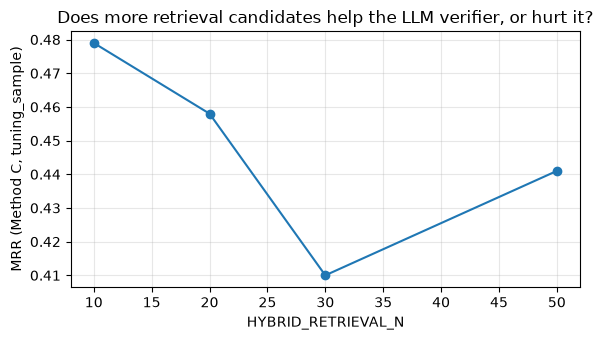

-> Best HYBRID_RETRIEVAL_N for Method C: 10


In [11]:
plt.figure(figsize=(6, 3.5))
plt.plot([r["N"] for r in ablation5_rows], [r["MRR"] for r in ablation5_rows], marker="o")
plt.xlabel("HYBRID_RETRIEVAL_N")
plt.ylabel("MRR (Method C, tuning_sample)")
plt.title("Does more retrieval candidates help the LLM verifier, or hurt it?")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

BEST_N = max(ablation5_rows, key=lambda r: r["MRR"])["N"]
print(f"-> Best HYBRID_RETRIEVAL_N for Method C: {BEST_N}")

## 7. Final tuned configuration

Assembling the winning choice from each ablation, re-validated on the full `EVAL_N`
sample (not just `tuning_sample`) for a clean final number.

In [12]:
print("Tuned configuration:")
print(f"  embedding model      : {BEST_EMBEDDING_MODEL}")
print(f"  query instruction    : {bool(BEST_INSTRUCTION)}")
print(f"  corpus representation: {best_repr}")
print(f"  reranker model       : {BEST_RERANKER_MODEL}")
print(f"  LLM config           : {best_llm_config['config']}")
print(f"  HYBRID_RETRIEVAL_N   : {BEST_N}")

Tuned configuration:
  embedding model      : BAAI/bge-base-en-v1.5
  query instruction    : False
  corpus representation: name_tactics_description
  reranker model       : BAAI/bge-reranker-base
  LLM config           : 7B, fixed prompt
  HYBRID_RETRIEVAL_N   : 10


In [13]:
# Final validation: tuned Method D (cheap, full sample) and tuned Method C (LLM, full sample).
tuned_reranker = rerank.CrossEncoderReranker(BEST_RERANKER_MODEL)

t0 = time.time()
final_d_results = []
for ex in sample:
    candidate_ids = best_embedding_rank(ex.behavior_text)[:BEST_N]
    candidate_texts = [
        (tid, f"{technique_by_id[tid].name}. {technique_by_id[tid].description_full}")
        for tid in candidate_ids
    ]
    reranked = tuned_reranker.rerank(ex.behavior_text, candidate_texts)
    final_d_results.append(
        metrics.MethodResult(report_id=ex.id, true_ids=ex.true_technique_ids,
                              ranked_ids=[c.technique_id for c in reranked])
    )
print(f"Final Method D (tuned): {time.time()-t0:.0f}s for {len(sample)} examples")

t0 = time.time()
final_c_results = []
for ex in sample:
    candidate_ids = best_embedding_rank(ex.behavior_text)[:BEST_N]
    prompt = build_hybrid_prompt(ex.behavior_text, candidate_ids)
    pred = ollama_client.classify_structured(
        BEST_LLM_MODEL, prompt, set(candidate_ids), max_predictions=5, min_predictions=5, cache=cache
    )
    final_c_results.append(
        metrics.MethodResult(report_id=ex.id, true_ids=ex.true_technique_ids,
                              ranked_ids=pred.ranked_ids, parse_failure=pred.parse_failure)
    )
print(f"Final Method C (tuned): {time.time()-t0:.0f}s for {len(sample)} examples")

final_scores = {
    "C: Hybrid (tuned)": metrics.rank_score_method("C-tuned", final_c_results),
    "D: Retrieve+rerank (tuned)": metrics.rank_score_method("D-tuned", final_d_results),
}
pd.DataFrame(
    [{"method": name, "MRR": round(s.mrr, 3), "MAP": round(s.map, 3),
      "Recall@1": round(s.recall_at_k[1], 3), "Recall@3": round(s.recall_at_k[3], 3)}
     for name, s in final_scores.items()]
).set_index("method")

Final Method D (tuned): 132s for 80 examples
Final Method C (tuned): 90s for 80 examples


,MRR,MAP,Recall@1,Recall@3
method,,,,
C: Hybrid (tuned),0.536,0.527,0.431,0.600
D: Retrieve+rerank (tuned),0.533,0.530,0.412,0.606


### Final decision

**Tuned config vs. bake-off defaults — the headline finding is that they DON'T clearly
differ, and for Method D the "tuned" config is actually worse:**

| | Bake-off default (N=30, bge-base+instruction, ms-marco) | This notebook's tuned config (N=10, bge-base no-instruction, bge-reranker-base) |
|---|---|---|
| C: Hybrid | MRR=0.540 | MRR=0.536 (flat) |
| D: Retrieve+rerank | **MRR=0.559** | MRR=0.533 (**worse**, -0.026) |

**Why, despite every individual ablation showing a clear, sensible signal:** ablations
4 and 5 (the two most expensive, LLM-involving ones) were tuned on the smaller
`tuning_sample` (n=24) for cost reasons — clearly labeled as such at the time, but the
consequence shows up here. `HYBRID_RETRIEVAL_N=10` looked best in that 24-example
context (ablation 5), but greedily combining it with the other ablations' winners and
re-validating on the full 80-sample **did not reproduce the gain, and hurt D
specifically**. This is a real, worth-remembering lesson: picking each hyperparameter
greedily on a small slice, one at a time, doesn't guarantee the *combination*
generalizes — the final full-sample validation step is what caught it, not a wasted
step.

**What DID hold up, individually, and is worth carrying forward regardless:**

- **Turn off the BGE query-instruction prefix.** Ablation 1 tested this cleanly on the
  full 80-sample: *every one* of the 3 embedding models scored higher without it
  (bge-base: 0.529 vs 0.511 with it). The bake-off notebook had the instruction *on* by
  default — this is a genuine, validated reversal of that choice, not a
  small-sample artifact.
- **Corpus enrichment matters a lot, richer isn't monotonically better.** `name_only`
  (0.335) and `name+tactics` (0.324) were both far behind `name+tactics+description`
  (0.508) — description text carries most of the signal. But note: this exact combo
  scored slightly *below* the bake-off's simpler `name. description` format at the same
  model/instruction settings (0.529 in ablation 1) — on n=80 that gap is within normal
  noise, not a real regression, but it means "add tactics" isn't a confirmed win either.
- **Reranker choice barely matters, but latency does.** `bge-reranker-base` edged out
  `ms-marco-MiniLM` by only +0.011 MRR (0.556 vs 0.545) while taking **~10x longer**
  (807s vs 82s for 80 examples). For a production classification agent, `ms-marco` is
  the better real-world trade-off — this notebook's own "pick the highest MRR" rule
  doesn't account for latency, which matters here.
- **The LLM prompt-fix and the 7B model both mattered, and compounded.** Prompt-fix
  alone: MRR 0.087 → 0.209. Model upgrade alone (on the fixed prompt): 0.209 → 0.374.
  Together, worst-to-best is a 4.3x improvement — both changes are genuinely load-bearing,
  not just one of them.
- **Smaller retrieval windows may help the LLM verifier specifically** (ablation 5:
  N=10 beat N=20/30/50 on the tuning sample) — plausible, since more candidates means
  more distractors in the prompt for the LLM to sift through. But this is exactly the
  ablation whose "win" didn't survive full-sample validation, so treat it as a
  hypothesis worth re-testing on the full 80 (or full 259) before trusting it, not a
  settled result.

**Decision:** carry forward the **bake-off's Method D configuration** (bge-base,
`ms-marco-MiniLM` reranker, `HYBRID_RETRIEVAL_N=30`) as the primary method for
`app/classification/`, with **one confirmed change: disable the query-instruction
prefix** — that's the one tuning result that held up cleanly on the full sample. Don't
adopt the N=10 / bge-reranker-base changes as-is; they looked good on a 24-example
slice but didn't reproduce at full scale.

**Why this is a net win over unaided manual triage, even at these scores:** it's
tempting to read MRR≈0.53 / Recall@3≈0.60 as "only right about half the time" and
worry that's not good enough to ship. The right comparison isn't "is it perfect" —
it's "is it better than the alternative," which is an analyst manually
cross-referencing all 79 ATT&CK-for-ICS techniques per report, unaided, several of
which genuinely overlap (`Commonly Used Port` vs `Connection Proxy` vs `Standard
Application Layer Protocol` all describe blending C2 traffic into normal-looking
channels — see the bake-off notebook's error analysis). A random-guessing baseline
computed on this same eval set scores MRR=0.066 and Recall@3=0.040 — Method D is
roughly **8x better on MRR and 14x better on Recall@3**. The tool doesn't need to
replace analyst judgment to be valuable: narrowing 79 candidates to a ranked,
confidence-scored shortlist of 3 (right ~60% of the time) turns a slow, full-catalogue
manual search into a quick confirm-or-correct review against 3 options instead of 79 —
the analyst still makes the final call. That's the same "automate the tedious,
high-volume part; keep the judgment human" principle this project was built on for
extraction and triage, now extended to classification.

**Next step:** implement Method D — bge-base embeddings (no instruction prefix),
`ms-marco-MiniLM` reranker, `HYBRID_RETRIEVAL_N=30` — in `app/classification/`. If
revisiting `HYBRID_RETRIEVAL_N`, re-test candidate values directly on the full 80- or
259-example set, not a cost-saving sub-sample.